In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle
df = pd.read_csv('../data/spam_islenmis.csv')
df = df.dropna(subset=['metin_islenmis'])  # o 1 boş satırı at

# X = giriş (metin), y = çıkış (0 veya 1)
X = df['metin_islenmis']
y = df['label']

print(f"Toplam veri: {len(df)}")
print(f"Spam: {y.sum()} | Gerçek: {(y==0).sum()}")

Toplam veri: 5569
Spam: 747 | Gerçek: 4822


In [2]:
# %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # %20 test
    random_state=42,     # her seferinde aynı bölünme
    stratify=y           # spam oranı eğitim ve testte eşit olsun
)

print(f"Eğitim seti: {len(X_train)} satır")
print(f"Test seti:   {len(X_test)} satır")

Eğitim seti: 4455 satır
Test seti:   1114 satır


In [3]:
tfidf = TfidfVectorizer(max_features=5000)  # en önemli 5000 kelime

X_train_tfidf = tfidf.fit_transform(X_train)  # eğitim verisinden öğren + dönüştür
X_test_tfidf  = tfidf.transform(X_test)       # sadece dönüştür (öğrenme yok!)

print(f"Matris boyutu: {X_train_tfidf.shape}")
# (4458, 5000) → 4458 e-posta, 5000 kelime özelliği

Matris boyutu: (4455, 5000)


In [4]:
# Model 1: Lojistik Regresyon
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
print("Lojistik Regresyon eğitildi ✓")

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
print("Random Forest eğitildi ✓")

Lojistik Regresyon eğitildi ✓
Random Forest eğitildi ✓


In [5]:
def metrikleri_hesapla(model_adi, y_gercek, y_tahmin):
    print(f"\n{'='*40}")
    print(f"  {model_adi}")
    print(f"{'='*40}")
    print(f"Accuracy  (Doğruluk) : %{accuracy_score(y_gercek, y_tahmin)*100:.2f}")
    print(f"Precision (Kesinlik) : %{precision_score(y_gercek, y_tahmin)*100:.2f}")
    print(f"Recall    (Duyarlılık): %{recall_score(y_gercek, y_tahmin)*100:.2f}")
    print(f"F1 Score             : %{f1_score(y_gercek, y_tahmin)*100:.2f}")

# Lojistik Regresyon
lr_tahmin = lr_model.predict(X_test_tfidf)
metrikleri_hesapla("Lojistik Regresyon", y_test, lr_tahmin)

# Random Forest
rf_tahmin = rf_model.predict(X_test_tfidf)
metrikleri_hesapla("Random Forest", y_test, rf_tahmin)


  Lojistik Regresyon
Accuracy  (Doğruluk) : %96.77
Precision (Kesinlik) : %92.48
Recall    (Duyarlılık): %82.55
F1 Score             : %87.23

  Random Forest
Accuracy  (Doğruluk) : %98.47
Precision (Kesinlik) : %99.25
Recall    (Duyarlılık): %89.26
F1 Score             : %93.99


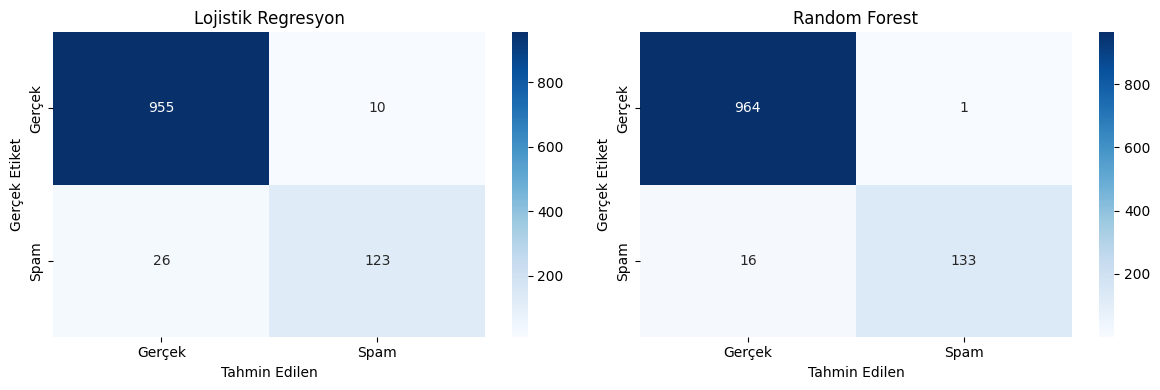

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, tahmin, baslik in zip(axes, 
                               [lr_tahmin, rf_tahmin], 
                               ['Lojistik Regresyon', 'Random Forest']):
    cm = confusion_matrix(y_test, tahmin)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Gerçek','Spam'], 
                yticklabels=['Gerçek','Spam'])
    ax.set_title(baslik)
    ax.set_ylabel('Gerçek Etiket')
    ax.set_xlabel('Tahmin Edilen')

plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

In [7]:
import pickle

with open('../models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Modeller kaydedildi ✓")

Modeller kaydedildi ✓
